In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Section 2: Model Training (Random Forest)

### What You Will Do

* Define features and target variable
* Train a Random Forest model
* Evaluate model performance
* Interpret results using SHAP

### Key Idea

Random Forest is an ensemble model built from many decision trees.

Key parameters (e.g., number of trees, depth) control model performance and complexity.

SHAP helps explain how each feature contributes to the model predictions.



####<font color="#FF69B4">PROMPT: "Please set the working directory to /content/drive/MyDrive/WORKSHOP-Intro-ML-Predict-DO"

In [2]:
import os

working_directory = '/content/drive/MyDrive/WORKSHOP-Intro-ML-Predict-DO'
os.chdir(working_directory)
print(f"Working directory set to: {os.getcwd()}")

Working directory set to: /content/drive/MyDrive/WORKSHOP-Intro-ML-Predict-DO


####<font color="#FF69B4">PROMPT: "Please load the "CBP_CleanedData/Final_Upper_StationCB3.2.csv" as df "

In [3]:
import pandas as pd

# Define the file path relative to the current working directory
file_path = "CBP_CleanedData/Final_Upper_StationCB3.2.csv"

# Load the CSV file into a DataFrame named 'df'
df = pd.read_csv(file_path)

print(f"DataFrame '{file_path}' loaded successfully.")
print(df.head())

DataFrame 'CBP_CleanedData/Final_Upper_StationCB3.2.csv' loaded successfully.
  MonitoringStation  SampleDate  CHLA  SALINITY       TN     TP  WTEMP   DO
0             CB3.2  1984-07-12   2.7      1.01  1.39600  0.063   24.5  4.4
1             CB3.2  1984-07-25   5.3      0.79  1.53375  0.070   26.0  1.3
2             CB3.2  1984-08-07  17.4      3.06  1.21200  0.044   26.2  0.0
3             CB3.2  1984-08-30   6.0      6.87  1.03900  0.041   25.3  2.6
4             CB3.2  1984-09-12   7.3      7.87  0.57350  0.031   23.1  2.7


####<font color="#FF69B4">PROMPT: "Please use df, set CHLA, SALINITY, TN, TP, and WTEMP as the feature variabes X, set DO as the target variable y."

In [4]:
features = ['CHLA', 'SALINITY', 'TN', 'TP', 'WTEMP']
target = 'DO'

X = df[features]
y = df[target]

print(f"Feature variables (X): {features}")
print(f"Target variable (y): {target}")
print("Shape of features (X):", X.shape)
print("Shape of target (y):", y.shape)

Feature variables (X): ['CHLA', 'SALINITY', 'TN', 'TP', 'WTEMP']
Target variable (y): DO
Shape of features (X): (617, 5)
Shape of target (y): (617,)


####<font color="#FF69B4">PROMPT: "Please split the X and y into training and testing sets using an 80/20 ratio."

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (493, 5)
X_test shape: (124, 5)
y_train shape: (493,)
y_test shape: (124,)


####<font color="#FF69B4">PROMPT: "Please train a Random Forest Regressor with 100 trees using the training data, name the model rf_model. Then, evaluate its performance on the test set using RMSE and R²."

In [6]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Initialize the Random Forest Regressor model
# Using a random_state for reproducibility
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

# Fit the model to the training data
rf_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = rf_model.predict(X_test)

# Evaluate the model's performance
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Random Forest Regressor Performance on Test Set:")
print(f"RMSE: {rmse:.4f}")
print(f"R-squared: {r2:.4f}")

Random Forest Regressor Performance on Test Set:
RMSE: 1.6981
R-squared: 0.7178


####<font color="#FF69B4">PROMPT: "Please plot the predicted and true DO values to visually assess rf_model performance."

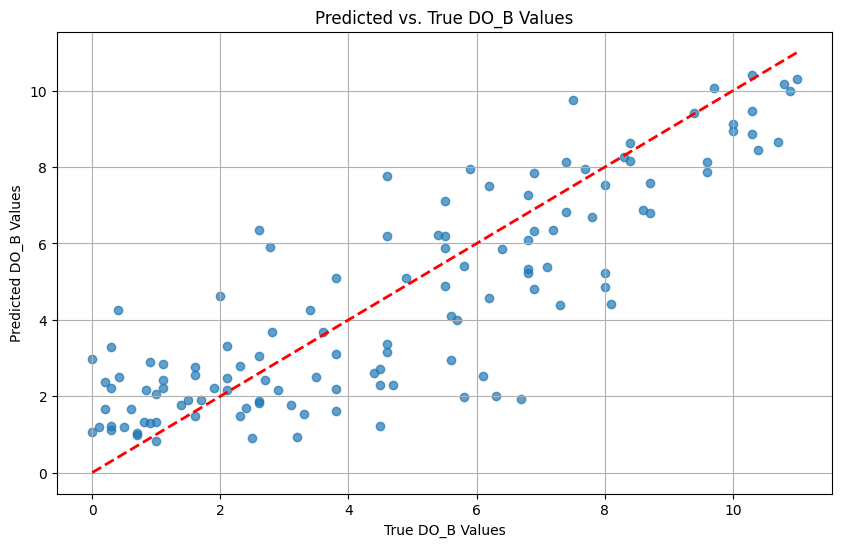

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) # Diagonal line for perfect prediction
plt.xlabel('True DO_B Values')
plt.ylabel('Predicted DO_B Values')
plt.title('Predicted vs. True DO_B Values')
plt.grid(True)
plt.show()

####<font color="#FF69B4">PROMPT: "Please plot one decision tree from the rf_model to show how it makes predictions using splits on the input variables. Please set the maximum tree depth to 3."

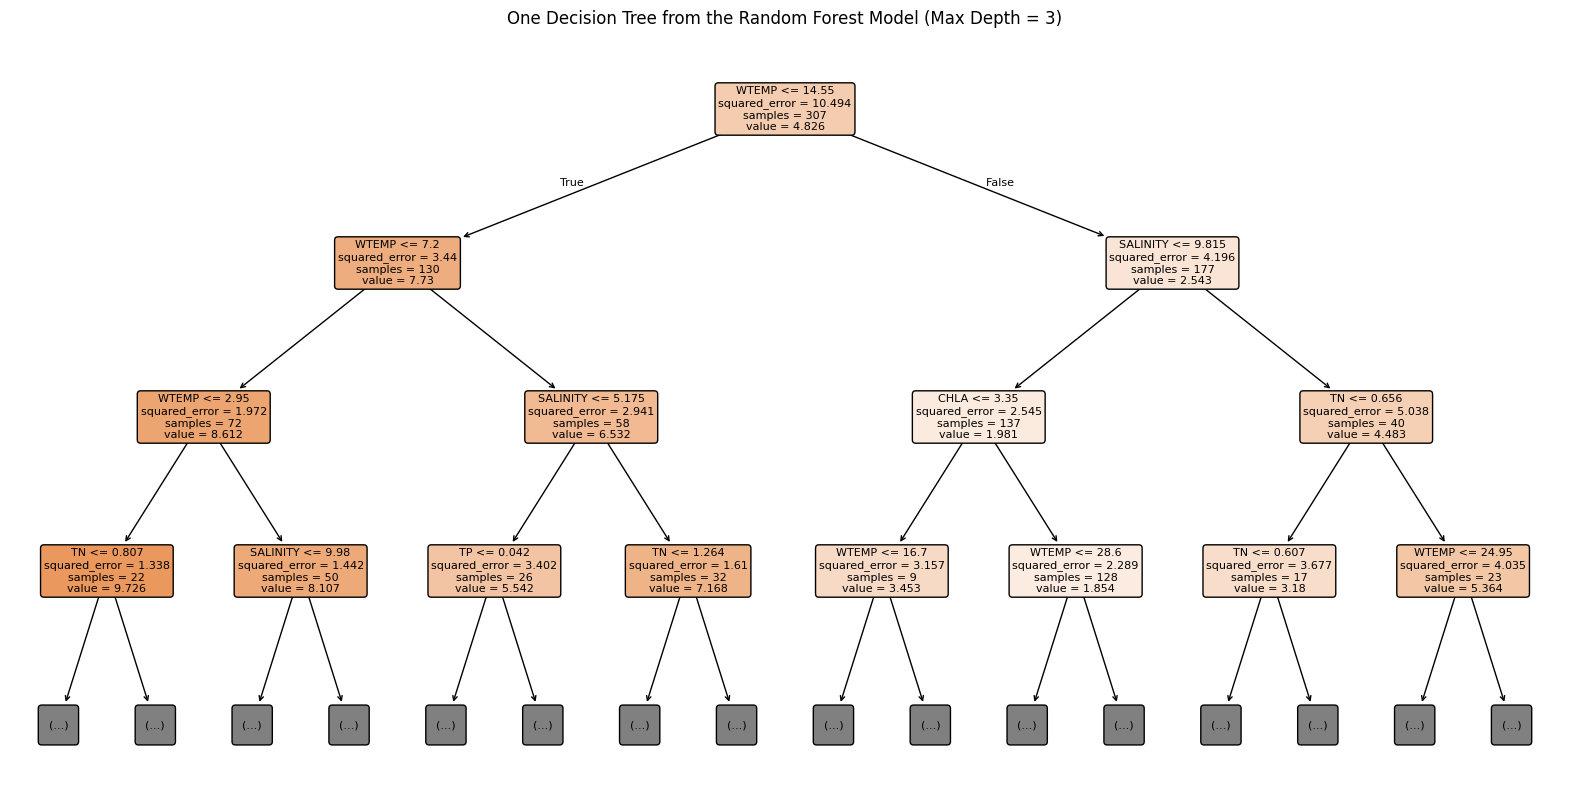

In [8]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# Choose one of the estimators (decision trees) from the Random Forest model
# We'll pick the first one for simplicity
estimator = rf_model.estimators_[0]

plt.figure(figsize=(20, 10)) # Adjust figure size for better readability
plot_tree(estimator,
          feature_names=X.columns.tolist(), # Use the actual feature names
          filled=True,
          rounded=True,
          fontsize=8,
          max_depth=3) # Set maximum depth as requested
plt.title('One Decision Tree from the Random Forest Model (Max Depth = 3)')
plt.show()

####<font color="#FF69B4">PROMPT: "Please use SHAP (SHapley Additive exPlanations) to interpret how each feature contributes to the rf_model predictions."

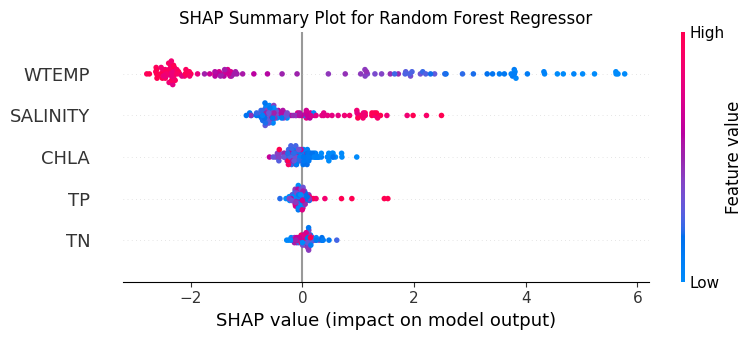

In [9]:
# Install SHAP if not already installed
# !pip install shap

import shap
import matplotlib.pyplot as plt

# Create a SHAP TreeExplainer for the Random Forest model
# TreeExplainer is optimized for tree-based models
explainer = shap.TreeExplainer(rf_model)

# Calculate SHAP values for the test set
# Using a subset of X_test for faster computation if the test set is large
# shap_values = explainer.shap_values(X_test)
# For a full interpretation, use the entire X_test
shap_values = explainer.shap_values(X_test)

# Visualize the feature contributions using a summary plot
# This plot shows the importance of each feature and its impact on the model output
shap.summary_plot(shap_values, X_test, feature_names=X.columns.tolist(), show=False)
plt.title('SHAP Summary Plot for Random Forest Regressor')
plt.tight_layout()
plt.show()

####<font color="#FF69B4">PROMPT:" Please show the average absolute contribution of each feature to the model predictions."

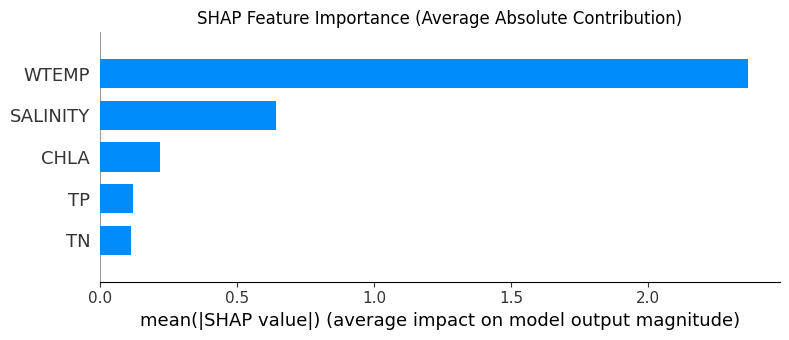

In [10]:
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.title('SHAP Feature Importance (Average Absolute Contribution)')
plt.tight_layout()
plt.show()

####<font color="#FF69B4">PROMPT:" Please create the folder SavedModels/RF/Run_1"

In [11]:
import os

folder_path = 'SavedModels/RF/Run_1'
os.makedirs(folder_path, exist_ok=True)
print(f"Folder '{folder_path}' created successfully (or already exists).")

Folder 'SavedModels/RF/Run_1' created successfully (or already exists).


####<font color="#FF69B4">PROMPT:" Please save the trained Random Forest model in the Run_1 folder. Also, save the following information: training data used, target and feature list, train/test split ratio, number of trees

In [14]:
import os
import joblib

# Define the folder to save the model and metadata
save_folder = 'SavedModels/RF/Run_1'

# Ensure the folder exists (it should already exist from a previous step)
os.makedirs(save_folder, exist_ok=True)

# Define the paths for the model and metadata files
model_filename = 'rf_model.pkl'
metadata_filename = 'rf_model_metadata.pkl'

model_path = os.path.join(save_folder, model_filename)
metadata_path = os.path.join(save_folder, metadata_filename)

# Save the trained Random Forest model
joblib.dump(rf_model, model_path)
print(f"Trained Random Forest model saved to: {model_path}")

# Gather the information to save
model_metadata = {
    'training_data_file': file_path, # The file path of the training data
    'training_data_shape_X': X_train.shape,
    'training_data_shape_y': y_train.shape,
    'feature_list': features,
    'target_variable': target,
    'train_test_split_ratio': '80/20',
    'test_size': 0.2, # As used in train_test_split
    'random_state_split': 42, # Assuming 42 was used for train_test_split
    'n_estimators': rf_model.n_estimators,
    'random_state_model': rf_model.random_state # Random state used for the RF model
}

# Save the metadata
joblib.dump(model_metadata, metadata_path)
print(f"Model metadata saved to: {metadata_path}")

print("\nSaved Metadata:")
for key, value in model_metadata.items():
    print(f"  {key}: {value}")

Trained Random Forest model saved to: SavedModels/RF/Run_1/rf_model.pkl
Model metadata saved to: SavedModels/RF/Run_1/rf_model_metadata.pkl

Saved Metadata:
  training_data_file: CBP_CleanedData/Final_Upper_StationCB3.2.csv
  training_data_shape_X: (493, 5)
  training_data_shape_y: (493,)
  feature_list: ['CHLA', 'SALINITY', 'TN', 'TP', 'WTEMP']
  target_variable: DO
  train_test_split_ratio: 80/20
  test_size: 0.2
  random_state_split: 42
  n_estimators: 100
  random_state_model: 42


### <font color="#F67">**Congratulations! You’ve trained a Random Forest model on real Chesapeake Bay water quality data to predict bottom dissolved oxygen (DO). Now, let’s move on to training an MLP model!**